In [2]:
import pandas as pd
import numpy as np
from plotnine import *

In [3]:
df = pd.DataFrame({
    "city_country": [
        "Augzin, Germany",
        "Burgfeld, Germany",
        "Ketting, Denmark",
        "Toga, France",
        "Chevalet, France",
        "Willishausen, Germany",
        "Aase, Denmark"
    ],
    "juice_consumption": [5, 3, 2, 10, 7, 4, 9],
    "water_consumption": [5, 8, 6, 9, 10, 2, 4]
})

df.head()

,city_country,juice_consumption,water_consumption
0,"Augzin, Germany",5,5
1,"Burgfeld, Germany",3,8
2,"Ketting, Denmark",2,6
3,"Toga, France",10,9
4,"Chevalet, France",7,10


In [4]:
df[['city', 'country']] = df['city_country'].str.split(',', expand= True)
df.drop(columns= 'city_country', inplace= True)
df.head()

,juice_consumption,water_consumption,city,country
0,5,5,Augzin,Germany
1,3,8,Burgfeld,Germany
2,2,6,Ketting,Denmark
3,10,9,Toga,France
4,7,10,Chevalet,France


In [5]:
df = df.iloc[:, [3,2,1,0]]
df.head()

,country,city,water_consumption,juice_consumption
0,Germany,Augzin,5,5
1,Germany,Burgfeld,8,3
2,Denmark,Ketting,6,2
3,France,Toga,9,10
4,France,Chevalet,10,7


In [6]:
df = df.melt(id_vars=['country', 'city'], value_vars= ['water_consumption', 'juice_consumption'], var_name= 'product', value_name= 'magnitude')
myDict = {'water_consumption': 'water', 'juice_consumption':'juice'}
df['product'] = df['product'].map(myDict)


In [7]:
df.groupby(['city','product']).agg({'magnitude': 'mean'}).reset_index()

,city,product,magnitude
0,Aase,juice,9.0
1,Aase,water,4.0
2,Augzin,juice,5.0
3,Augzin,water,5.0
4,Burgfeld,juice,3.0
5,Burgfeld,water,8.0
6,Chevalet,juice,7.0
7,Chevalet,water,10.0
8,Ketting,juice,2.0
9,Ketting,water,6.0


---------

# Melt Function

In [8]:
df = pd.DataFrame({
    'city': ['Berlin', 'Berlin', 'Munich', 'Munich', 'Hamburg', 'Hamburg'],
    'year': [2023, 2024, 2023, 2024, 2023, 2024],
    'water': [120, 130, 100, 110, 90, 95],
    'juice': [80, 85, 70, 75, 60, 65],
    'soda': [50, 55, 40, 45, 30, 35]
})

df

,city,year,water,juice,soda
0,Berlin,2023,120,80,50
1,Berlin,2024,130,85,55
2,Munich,2023,100,70,40
3,Munich,2024,110,75,45
4,Hamburg,2023,90,60,30
5,Hamburg,2024,95,65,35


In [9]:
df_melted = df.melt(id_vars= ['city','year'], 
                    value_vars= ['water', 'juice', 'soda'],
                    var_name= 'drink', 
                    value_name= 'consumption')

df_melted.head()

,city,year,drink,consumption
0,Berlin,2023,water,120
1,Berlin,2024,water,130
2,Munich,2023,water,100
3,Munich,2024,water,110
4,Hamburg,2023,water,90


In [10]:
df_pivot = df_melted.pivot(
    index = ['city', 'year'],
    columns= 'drink',
    values= 'consumption' 
).reset_index()

df_pivot.head()

drink,city,year,juice,soda,water
0,Berlin,2023,80,50,120
1,Berlin,2024,85,55,130
2,Hamburg,2023,60,30,90
3,Hamburg,2024,65,35,95
4,Munich,2023,70,40,100


---------

# Str Split 

In [11]:
df = pd.DataFrame({
    "city_country": [
        "Berlin, Germany",
        "Munich,Germany",
        "Hamburg , Germany",
        "Paris, France",
        "Lyon,France",
        "Copenhagen, Denmark",
        "Aarhus,Denmark",
        "New York, USA",
        "Los Angeles, USA",
        "Mexico City, Mexico"
    ],
    "juice_consumption": [5, 3, 4, 10, 7, 2, 6, 8, 9, 11],
    "water_consumption": [7, 8, 6, 9, 10, 5, 6, 7, 8, 9]
})

df.head()

,city_country,juice_consumption,water_consumption
0,"Berlin, Germany",5,7
1,"Munich,Germany",3,8
2,"Hamburg , Germany",4,6
3,"Paris, France",10,9
4,"Lyon,France",7,10


In [12]:
df[['city', 'country']] = df['city_country'].str.split(',', expand= True).apply(lambda s : s.str.strip())

df = df[['city', 'country', 'juice_consumption', 'water_consumption']]


In [13]:
df.rename(columns={'juice_consumption':'juice','water_consumption':'water' }, inplace= True)
df.head()

,city,country,juice,water
0,Berlin,Germany,5,7
1,Munich,Germany,3,8
2,Hamburg,Germany,4,6
3,Paris,France,10,9
4,Lyon,France,7,10


In [14]:
df_melted = df.melt(id_vars= ['city', 'country'], value_vars= ['juice', 'water'], var_name= 'product', value_name= 'consumption')
df_melted.head()

,city,country,product,consumption
0,Berlin,Germany,juice,5
1,Munich,Germany,juice,3
2,Hamburg,Germany,juice,4
3,Paris,France,juice,10
4,Lyon,France,juice,7


In [15]:
df_group = df_melted.groupby(['city', 'product']).aggregate({'consumption': ['mean','sum']}).astype(int).reset_index()

In [16]:
df_group.head()

city product consumption    
                             mean sum
0      Aarhus   juice           6   6
1      Aarhus   water           6   6
2      Berlin   juice           5   5
3      Berlin   water           7   7
4  Copenhagen   juice           2   2

In [17]:
df_group.columns

MultiIndex([(       'city',     ''),
            (    'product',     ''),
            ('consumption', 'mean'),
            ('consumption',  'sum')],
           )

In [18]:
df_group[[('consumption', 'mean'), ('consumption','sum'), ('city','')]].head()

consumption            city
         mean sum            
0           6   6      Aarhus
1           6   6      Aarhus
2           5   5      Berlin
3           7   7      Berlin
4           2   2  Copenhagen

In [19]:
df_group2 = df_melted.groupby(['city', 'country']).agg(
    mean = ('consumption', 'mean'),
    sum = ('consumption', 'sum')
).astype(int).reset_index()

df_group2.head()

,city,country,mean,sum
0,Aarhus,Denmark,6,12
1,Berlin,Germany,6,12
2,Copenhagen,Denmark,3,7
3,Hamburg,Germany,5,10
4,Los Angeles,USA,8,17


--------

In [20]:
import pandas as pd

sales = pd.DataFrame({
    "date": ["2024-01", "2024-01", "2024-02", "2024-02", "2024-03", "2024-03"],
    "city": ["Berlin", "Munich", "Berlin", "Munich", "Berlin", "Munich"],
    "product": ["A", "A", "B", "B", "A", "B"],
    "sales": [100, 150, 200, 120, 130, 180]
})

In [21]:
sales.pivot(columns = 'product', index= ['date', 'city'], values= 'sales').reset_index().dropna(subset=['A', 'B'], how= 'all')

product,date,city,A,B
0,2024-01,Berlin,100.0,NaN
1,2024-01,Munich,150.0,NaN
2,2024-02,Berlin,NaN,200.0
3,2024-02,Munich,NaN,120.0
4,2024-03,Berlin,130.0,NaN
5,2024-03,Munich,NaN,180.0


---------

# Difference between Apply & Transform

In [22]:
import pandas as pd

df = pd.DataFrame({
    "group": ["A", "A", "B", "B", 'C', 'C'],
    "value": [10, 20, 30, 40, 50, 60 ],
    "value2": [10, 20, 30, 40, 50, 60 ]
})

👉 When working on a single column, they often look identical.

In [23]:
df['value'].transform(lambda p : print(f'{p}, bla'))

10, bla
20, bla
30, bla
40, bla
50, bla
60, bla


0    None
1    None
2    None
3    None
4    None
5    None
Name: value, dtype: object

In [24]:
df['value'].apply(lambda p : print(f'{p}, bla'))

10, bla
20, bla
30, bla
40, bla
50, bla
60, bla


0    None
1    None
2    None
3    None
4    None
5    None
Name: value, dtype: object

🔥 Now the Real Difference — GroupBy

In [25]:
df.groupby('group').apply(lambda x : print(f'{x}, bla'))

  group  value  value2
0     A     10      10
1     A     20      20, bla
  group  value  value2
2     B     30      30
3     B     40      40, bla
  group  value  value2
4     C     50      50
5     C     60      60, bla


/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_84702/3179833861.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


""


In [26]:
df.groupby('group').apply(lambda x : x['value'].mean())

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_84702/3754168974.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


group
A    15.0
B    35.0
C    55.0
dtype: float64

Using groupby().transform()

In [27]:
df.groupby('group')['value'].transform(lambda x : x.mean())

0    15.0
1    15.0
2    35.0
3    35.0
4    55.0
5    55.0
Name: value, dtype: float64

In [34]:
df.groupby('group').agg({'value':['mean', 'sum']}).reset_index()

group value     
         mean  sum
0     A  15.0   30
1     B  35.0   70
2     C  55.0  110

In [38]:
import pandas as pd

# Create the data
data = {
    "city": ["Munich", "Berlin", "Munich", "Munich", "Berlin", "Berlin"],
    "month": ["August", "August", "June", "July", "June", "July"],
    "population_thousands": [1604, 3432, 1604, 1604, 3432, 3432],
    "newly_infected": [1200, 1400, 900, 750, 360, 470]
}

df = pd.DataFrame(data)
df.head()

,city,month,population_thousands,newly_infected
0,Munich,August,1604,1200
1,Berlin,August,3432,1400
2,Munich,June,1604,900
3,Munich,July,1604,750
4,Berlin,June,3432,360


In [45]:
df['newly_infected_ratio'] = df['newly_infected'] / df['population_thousands']
df.head()

,city,month,population_thousands,newly_infected,newly_infected_ratio
0,Munich,August,1604,1200,0.748130
1,Berlin,August,3432,1400,0.407925
2,Munich,June,1604,900,0.561097
3,Munich,July,1604,750,0.467581
4,Berlin,June,3432,360,0.104895


In [61]:
df.groupby('city').agg({'newly_infected':'mean'}).reset_index()

,city,newly_infected
0,Berlin,743.333333
1,Munich,950.000000


In [67]:
df.groupby('city')['newly_infected'].sum().sort_values(ascending= False).index[0]

'Munich'

In [83]:
import pandas as pd

data = {
    "flight_num": ["AS1234", "AS1234",
                   "BC4512", "BC4512",
                   "DC9856", "DC9856",
                   "CH7012", "CH7012"],
    "origin": ["MUC", "MUC",
               "LHR", "LHR",
               "BLR", "BLR",
               "JFK", "JFK"],
    "destination": ["LAX", "LAX",
                    "MUC", "MUC",
                    "PNQ", "PNQ",
                    "BCN", "BCN"],
    "unit": ["hours", "minutes",
             "hours", "minutes",
             "hours", "minutes",
             "hours", "minutes"],
    "duration": [12, 15,
                 1, 50,
                 1, 15,
                 7, 15]
}

df = pd.DataFrame(data)

print(df)

  flight_num origin destination     unit  duration
0     AS1234    MUC         LAX    hours        12
1     AS1234    MUC         LAX  minutes        15
2     BC4512    LHR         MUC    hours         1
3     BC4512    LHR         MUC  minutes        50
4     DC9856    BLR         PNQ    hours         1
5     DC9856    BLR         PNQ  minutes        15
6     CH7012    JFK         BCN    hours         7
7     CH7012    JFK         BCN  minutes        15


In [84]:
df.head()

,flight_num,origin,destination,unit,duration
0,AS1234,MUC,LAX,hours,12
1,AS1234,MUC,LAX,minutes,15
2,BC4512,LHR,MUC,hours,1
3,BC4512,LHR,MUC,minutes,50
4,DC9856,BLR,PNQ,hours,1


In [85]:
df = df.pivot(index = df.columns[:-2], columns= 'unit', values= 'duration').reset_index()
df['duration'] = df['hours'] * 60 + df['minutes']

In [86]:
df.head()

unit,flight_num,origin,destination,hours,minutes,duration
0,AS1234,MUC,LAX,12,15,735
1,BC4512,LHR,MUC,1,50,110
2,CH7012,JFK,BCN,7,15,435
3,DC9856,BLR,PNQ,1,15,75


In [87]:
import pandas as pd

data = {
    "name": ["Luke Skywalker", "C-3PO", "R2-D2", "Darth Vader"],
    "height": [172, 167, 96, 202],
    "mass": [77, 75, 32, 136],
    "age": [19, 112, 33, 42],
    "sex": ["male", "none", "none", "male"],
    "homeworld": ["Tatooine", "Tatooine", "Naboo", "Tatooine"],
    "species": ["Human", "Droid", "Droid", "Human"]
}

df = pd.DataFrame(data)

print(df)

             name  height  mass  age   sex homeworld species
0  Luke Skywalker     172    77   19  male  Tatooine   Human
1           C-3PO     167    75  112  none  Tatooine   Droid
2           R2-D2      96    32   33  none     Naboo   Droid
3     Darth Vader     202   136   42  male  Tatooine   Human


In [88]:
df.head()

,name,height,mass,age,sex,homeworld,species
0,Luke Skywalker,172,77,19,male,Tatooine,Human
1,C-3PO,167,75,112,none,Tatooine,Droid
2,R2-D2,96,32,33,none,Naboo,Droid
3,Darth Vader,202,136,42,male,Tatooine,Human


In [91]:
df.groupby('species').apply(lambda g : (g['height']>200).sum()).reset_index(name = 'N')

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_84702/512634740.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,species,N
0,Droid,0
1,Human,1


In [95]:
import pandas as pd

data = {
    "candidate": ["Donald Trump", "Hillary Clinton"],
    "AK": ["260830/493176", "186014/493176"],
    "AL": ["2613850/4156330", "1436168/4156330"],
    "AR": ["1355808/2243368", "757458/2243368"],
    "AZ": ["2042308/4125620", "1872500/4125620"],
}

df = pd.DataFrame(data)

df.head()

,candidate,AK,AL,AR,AZ
0,Donald Trump,260830/493176,2613850/4156330,1355808/2243368,2042308/4125620
1,Hillary Clinton,186014/493176,1436168/4156330,757458/2243368,1872500/4125620


In [102]:
df.iloc[:,1:] = df.iloc[:,1:].map(lambda x : int(x.split('/')[0]) / int(x.split('/')[1]))

In [105]:
df.melt(id_vars= 'candidate', value_name='proportion')

,candidate,variable,proportion
0,Donald Trump,AK,0.528878
1,Hillary Clinton,AK,0.377176
2,Donald Trump,AL,0.628884
3,Hillary Clinton,AL,0.345538
4,Donald Trump,AR,0.604363
5,Hillary Clinton,AR,0.337643
6,Donald Trump,AZ,0.495031
7,Hillary Clinton,AZ,0.453871


In [114]:
import pandas as pd
import numpy as np

x = np.random.uniform(0,10, size= 100)
y = np.random.normal(loc = 5, scale = 2, size = 100)
z = np.random.choice([1,2], size= 100, replace = True)

df = pd.DataFrame({
    'x': x,
    'y': y,
    'group': z
})

df['group'] = df['group'].astype('category')

df.head()

,x,y,group
0,7.865051,9.020418,2
1,2.968987,7.335666,2
2,3.801881,5.842037,1
3,1.024898,6.466953,2
4,8.709992,5.014359,2


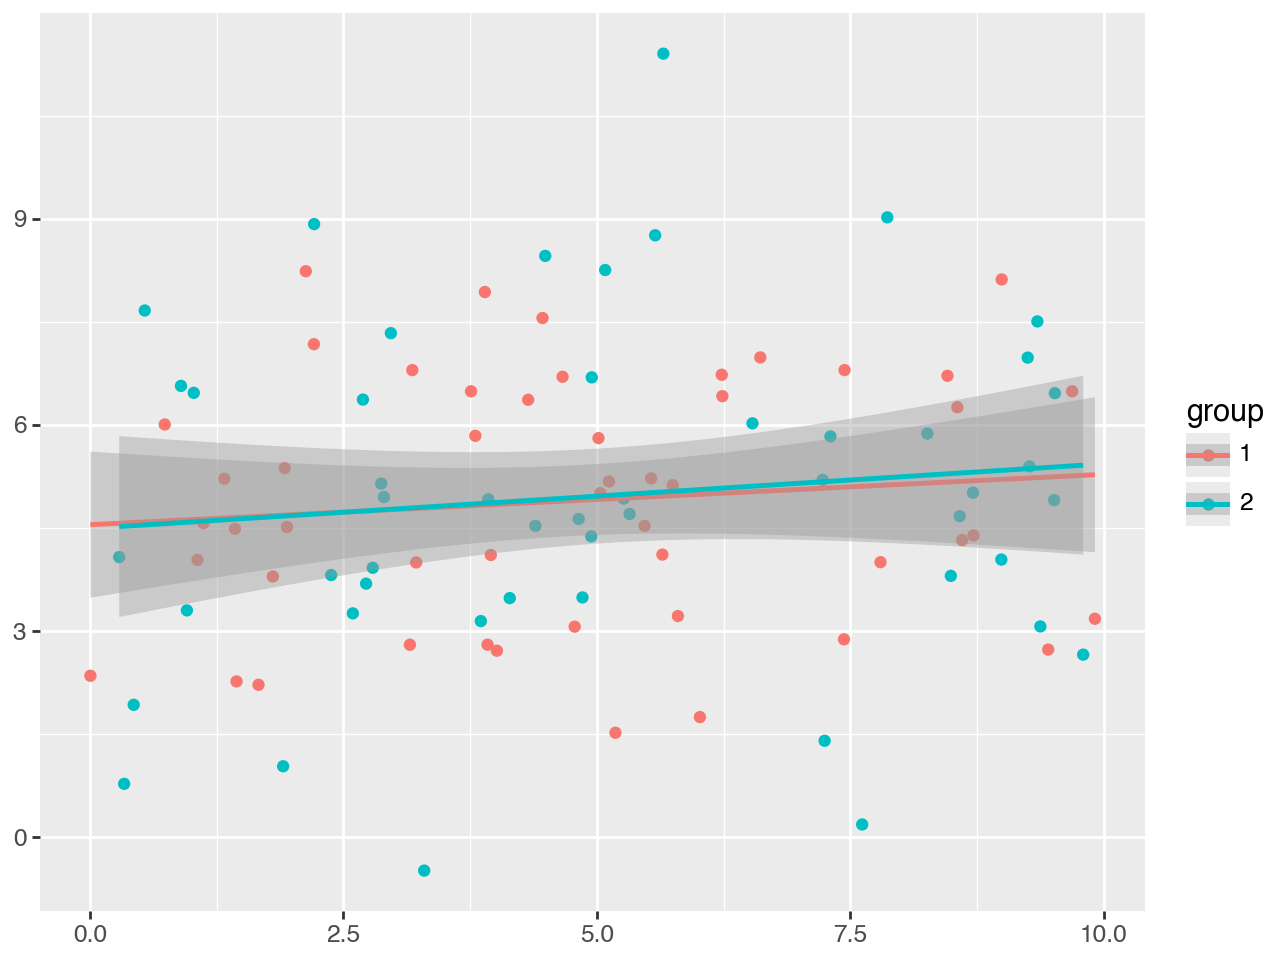

In [117]:
from plotnine import *

(
    ggplot(df, aes(x, y, color = 'group')) + 
    geom_point() + 
    geom_smooth(method = 'lm')
)

In [118]:
def isPrime(n):
        if n < 2:
            return False
        
        for i in range(2,n//2+1):
            if  n % i == 0:
                return False
        
        return True

In [128]:
numbers = np.arange(1,100001)
res = []
count = 0
for i in numbers:

    if isPrime(i):
        count += 1
    res.append(count)

In [129]:
df = pd.DataFrame({
    'x': numbers,
    'y': res
})

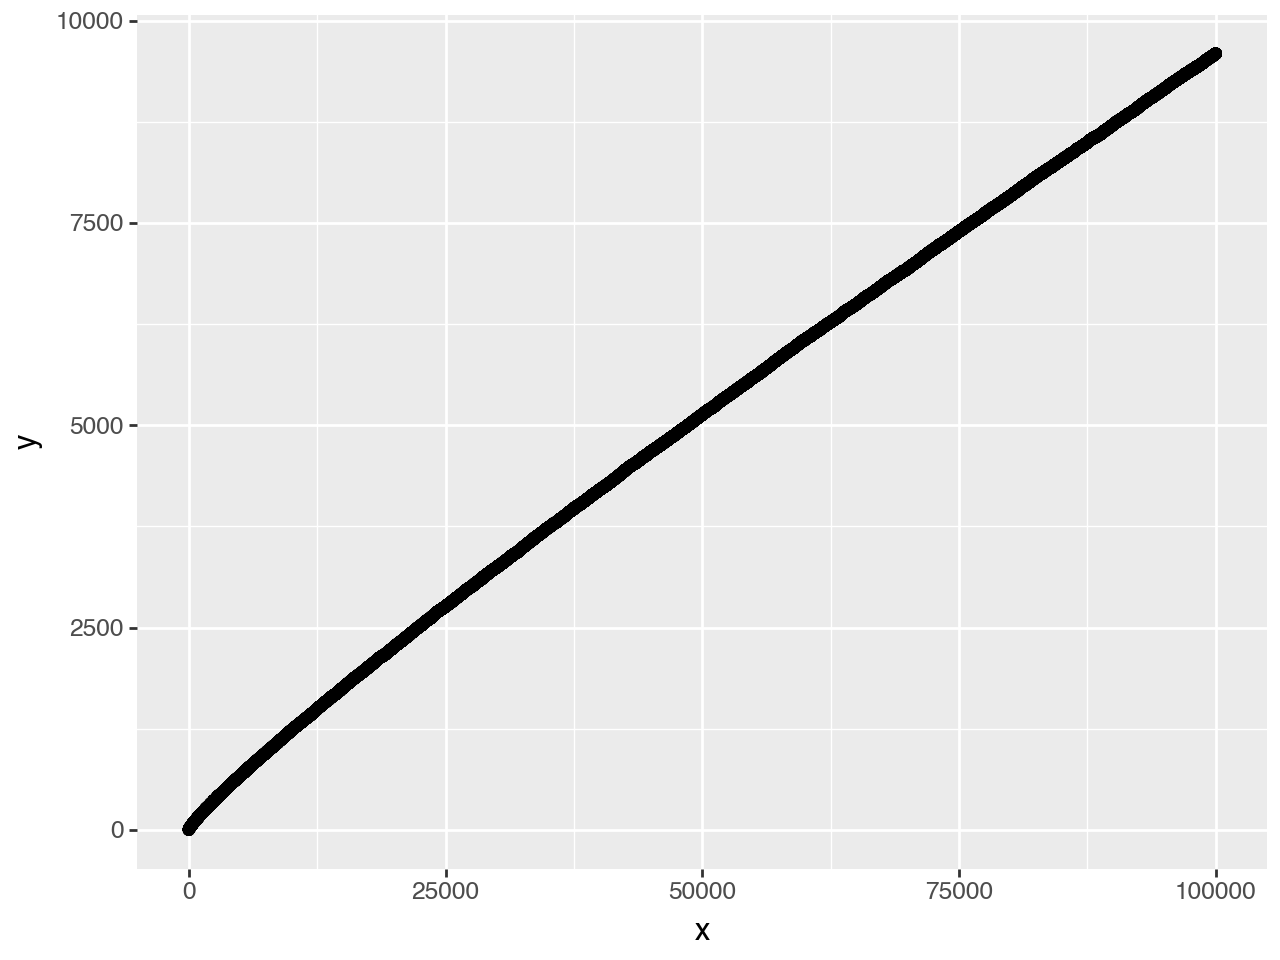

In [130]:
(
    ggplot(df, aes('x', 'y')) + 
    geom_point()
)

In [1]:
import numpy as np

rand_nums = np.random.randint(1, 11, 125)
print('['+ ','.join(map(str, rand_nums)) + ']')

[4,4,9,1,8,10,2,5,10,4,4,3,8,1,10,4,8,7,1,10,10,9,7,3,9,2,1,1,3,10,2,5,4,9,2,5,3,1,10,1,10,5,7,3,5,2,7,10,4,5,3,5,2,10,5,2,2,5,6,8,3,6,3,2,2,6,4,1,10,5,4,1,3,4,10,1,6,2,7,1,5,8,6,6,10,4,9,1,6,2,9,9,10,3,10,9,7,8,4,2,1,10,10,9,10,2,6,4,9,9,6,4,4,7,3,8,7,9,6,2,4,1,10,2,5]


In [31]:
import numpy as np

A = np.array([
    [2, 2, 2],
    [0, -1, 4],
    [5, 2, 0]
])

In [39]:
1 + False

1